In [1]:
from datetime import time
from os import times
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import math
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter

#math的相关函数，import后可以直接使用
from math import radians
from math import sin
from math import cos
from math import asin
from math import sqrt

# np.set_printoptions(threshold=np.inf)#显示所有的数组
from geopy.distance import great_circle
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
import seaborn as sns
from scipy import stats
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
import cartopy.mpl.ticker as cticker
from scipy.ndimage import gaussian_filter

In [2]:
infile = xr.open_dataset('E:/google/IBTrACS.WP.v04r01.nc')


# In[4]:


stayyy=1949
endyyy=2024
censea=infile['season']
indsea=np.where((censea>=stayyy)&(censea<=endyyy))
numsea=censea[indsea]


# In[5]:


tim=infile['time']
centim=tim.dt.month[:,0]
indtim=np.where((centim==7)|(centim==8)|(centim==9)|(centim==10))
numtim=tim[indtim]


# In[6]:


centyp=infile['track_type']
indtyp=np.where(centyp==b'main')
numtyp=centyp[indtyp]


# In[7]:


cenlat=infile['usa_lat']
nummia=np.sum(np.isnan(cenlat), axis=1)
numnma=np.sum(~np.isnan(cenlat), axis=1)  
minlat=np.amin(cenlat, axis=1)
minlat=np.amin(cenlat, axis=1)
indlat=np.where(numnma>=16)
numlat=cenlat[indlat]


# In[8]:


cenlon=infile['usa_lon']
nummio=np.sum(np.isnan(cenlon), axis=1) 
numnmo=np.sum(~np.isnan(cenlon), axis=1)  
minlon=np.amin(cenlon, axis=1)  
maxlon=np.amax(cenlon, axis=1) 
indlon=np.where(numnmo>=16)
numlon=cenlon[indlon]


# In[9]:


cenwin=infile['usa_wind']
nummiw=np.sum(np.isnan(cenwin), axis=1)   #每行nan个数
numnmw=np.sum(~np.isnan(cenwin), axis=1)  
maxwin = np.amax(cenwin, axis=1) 
indmaw = np.where(maxwin>=35) 
indwin = np.where((numnmw>=16)&(maxwin>=35))
numwin =cenwin[indwin]
# numwin


# In[10]:


cenatu=infile['nature']
numnat= np.sum(np.isin(cenatu, [b'DS', b'ET']), axis=1)#有多少个DS,ET,要这俩=0的地方
numb=np.sum(cenatu != b'', axis=1)#非空值的个数，用于去除空值以及小于48小时的情况,numb>16,3h
indnat=np.where((numb!=numnat)&(numb>16))


# In[11]:


lat = infile['usa_lat']

# 创建布尔掩码以筛选7、8、9月份的数据
mask = lat['time'].dt.month.isin([7, 8, 9])

# 保留掩码对应的数据并将其他数据设为NaN
lat2 = lat.where(mask, drop=True)

# 打印筛选后的数据以检查结果
# print(lat2)


# ## 登陆landindall_flat

# In[12]:


cendis=infile['dist2land']
nummid=np.sum(np.isnan(cendis), axis=1)   
numnmd=np.sum(~np.isnan(cendis), axis=1)  #非nan数
num0md=np.sum(cendis==0, axis=1) #每行几个0
inddis=np.where((numnmd>=16)&(num0md>0))  #0代表登陆，看有几个0
numdis=cendis[inddis]#登录的结果
landindall=[]
landindallin=[]
for j in range(1982,2024):  
    indall = np.where((censea==j)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35))
                    &((numb!=numnat)&(numb>=16))
                    &((numnmd>=16)&(num0md>0)))
    landindall.append(indall[0])
landindall_flat = np.concatenate(landindall).tolist()  # 将所有数组拼接并转换为列表


In [3]:
def sk(data):
    n=len(data)
    Sk     = [0]
    UFk    = [0]
    s      =  0
    E      = [0]
    Var    = [0]
    for i in range(1,n):
        for j in range(i):
            if data[i] > data[j]:
                s = s+1
            else:
                s = s+0
        Sk.append(s)
        E.append((i+1)*(i+2)/4 )                     # Sk[i]的均值
        Var.append((i+1)*i*(2*(i+1)+5)/72 )            # Sk[i]的方差
        UFk.append((Sk[i]-E[i])/np.sqrt(Var[i]))
    UFk=np.array(UFk)
    return UFk

def MK(data, a):
    ufk = sk(data)  # 顺序列
    ubk1 = sk(data[::-1])  # 逆序列
    ubk = -ubk1[::-1]  # 逆转逆序列
    
    # 创建年份范围作为横坐标
    years = np.arange(1982, 2024)  # 生成1982到2023年的数组
    
    # 输出突变点的位置
    p = []
    u = ufk - ubk
    for i in range(1, len(ufk)):
        if u[i-1] * u[i] < 0:
            p.append(i)
    if p:
        print("突变点位置：", p)
    else:
        print("未检测到突变点")
    
    # 画图
    conf_interval = stats.norm.interval(a, loc=0, scale=1)  # 获取置信区间
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号不显示问题
    plt.figure(figsize=(10, 5))
    
    # 使用年份作为横坐标
    plt.plot(years, ufk, label='UFk', color='r')
    plt.plot(years, ubk, label='UBk', color='b')
    
    plt.ylabel('UFk-UBk', fontsize=15)
    x_lim = plt.xlim()
    plt.ylim([-6, 7])
    
    # 绘制置信区间线
    plt.plot(x_lim, [conf_interval[0], conf_interval[0]], '--', color='r', label='95% Confidence Interval')
    plt.plot(x_lim, [conf_interval[1], conf_interval[1]], '--', color='r')
    plt.axhline(0, ls="--", c="k")
    
    # 图例设置
    plt.legend(loc='upper center', frameon=False, ncol=3, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel('Year', fontsize=15)
    plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_change_data(years, data, ylabel, title, split_index):
    """
    根据输入的年份、数据、分割点、纵坐标标签和图表标题绘制折线图，并标注前后平均值横线。
    
    Parameters:
    years (array-like): 年份序列。
    data (array-like): 对应年份的数值数据。
    ylabel (str): 纵坐标的标签。
    title (str): 图表的标题。
    split_index (int): 数据分割点，用于划分前后部分。
    """
    # 计算分割点之前和之后的平均值
    avg_prior = np.mean(data[:split_index])
    avg_post = np.mean(data[split_index:])
    
    # 绘制数据点及连线
    plt.plot(years, data, '-o', color='red')
    
    # 绘制分割点之前数据的平均值横线
    plt.plot(years[:split_index], [avg_prior] * split_index, color='blue', linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
    
    # 绘制分割点之后数据的平均值横线
    plt.plot(years[split_index:], [avg_post] * (len(years) - split_index), color='blue', linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
    
    # 添加坐标标签和标题
    plt.xlabel('Year', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.title(title,loc='left',fontsize=12)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    
    # 添加图例
    plt.legend(loc=1)

    
    P1 = data[:split_index]
    P2 =  data[split_index:]

    # 执行独立样本t检验，默认假设方差不等
    t_stat, p_value = stats.ttest_ind(P1, P2, equal_var=False)

    plt.title(f't: {t_stat:.2f}, P: {p_value:.2f}',loc='right',fontsize=12)
#     plt.text(1992, 1.05, f"Slope: {slope:.3f} ± {std_err:.3f}  per decade", fontsize=12, color='black')
    
    plt.show()
# split_index = 16  # 设置分割点为前16年和后24年
# plot_change_data(years, tomecur_totle, 'dist/km', 'Dist over Years', 17)


In [5]:
years = np.arange(1982, 2024)
split_index=17

突变点位置： [1, 4, 17]


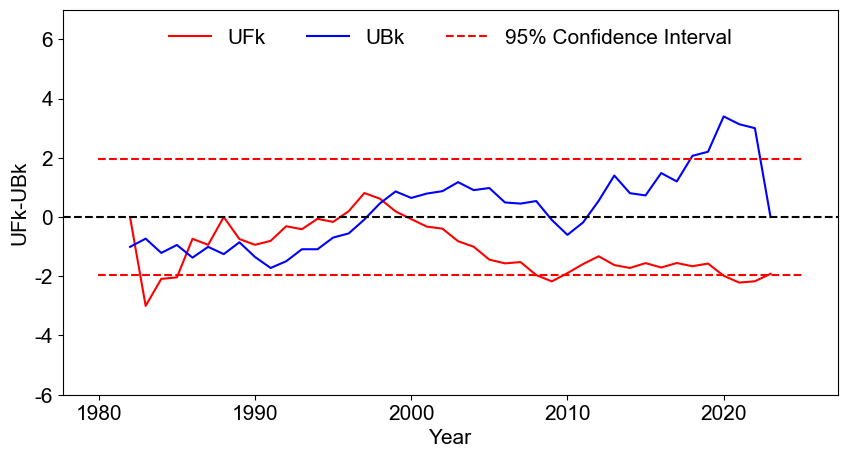

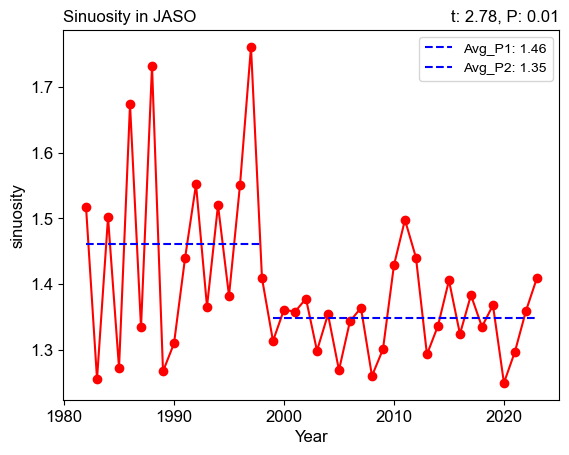

In [6]:
tomecur=[]
tonccur=[]
for j in range(1982,2024):  
    indall = np.where((censea==j)
                    &(centyp==b'main')
                    &((centim==7)|(centim==8)|(centim==9)|(centim==10))
                    &(numnma>=16)
                    &(numnmo>=16)
                    &((numnmw>=16)&(maxwin>=35))
                    &((numb!=numnat)&(numb>=16)))
    numatc=np.array(indall).shape[1]#台风个数tonccur

   
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        orilat=arrlat[0]
        endlat=arrlat[-1]
        
        orilon=arrlon[0]
        endlon=arrlon[-1]
       
        ori=[orilat,orilon]#起点集合
        end=[endlat,endlon]
        dist=great_circle(ori, end).kilometers#起点和终点的距离
        if dist!=0:
        
            coor=np.column_stack((arrlat, arrlon))#合并经纬度
            todist=0#总距离todist
            for k in range(len(coor) - 1):
                distall = great_circle(coor[k], coor[k+1]).kilometers
                todist += distall
            cur=todist/dist#一个台风的曲率
#             if cur<4.96:
#             print(cur)
            tocur.append(cur)
        mecur=np.mean(tocur)#平均曲率
    tomecur.append(mecur)#40yr平均曲率
tomecur_totle=tomecur

MK(tomecur,0.95)
plot_change_data(years,tomecur_totle, 'sinuosity', 'Sinuosity in JASO', 17)



In [7]:
data=tomecur
a=0.95
ufk = sk(data)  # 顺序列
ubk1 = sk(data[::-1])  # 逆序列
ubk = -ubk1[::-1]  # 逆转逆序列
years = np.arange(1982, 2024)  # 生成1982到2023年的数组
p = []
u = ufk - ubk
for i in range(1, len(ufk)):
    if u[i-1] * u[i] < 0:
        p.append(i)
if p:
    print("突变点位置：", p)
else:
    print("未检测到突变点")

# 画图
conf_interval = stats.norm.interval(a, loc=0, scale=1)  # 获取置信区间
plt.rcParams['axes.unicode_minus'] = False  # 解决负号不显示问题


突变点位置： [1, 4, 17]


## 1

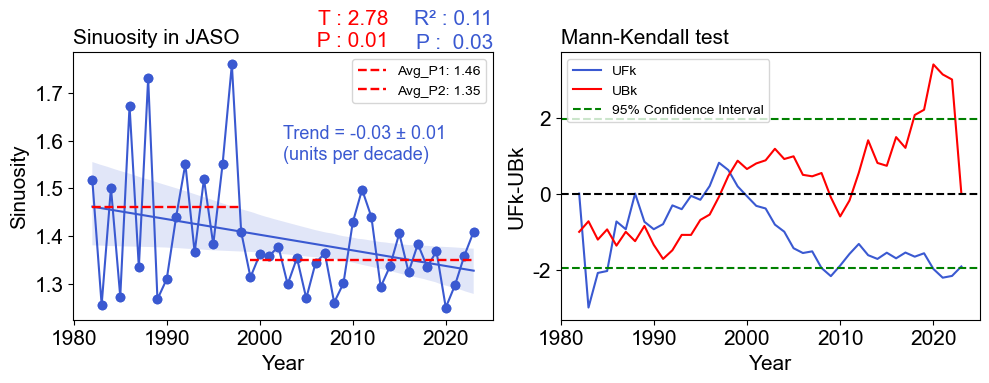

In [8]:
fig, axes = plt.subplots(1,2, figsize=(10, 4))
ax=axes[0]
split_index=17

color1='#3A59D1'
color2=color1
color3='r'



data=tomecur
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1,linewidth=1.5)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.5})
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--',linewidth=1.7, label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--',linewidth=1.7,
        label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Sinuosity', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Sinuosity in JASO',loc='left',fontsize=15)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
ax.text(0.5,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color1,
       transform=ax.transAxes)

ax.text(0.75, 1.16, f'T : {t_stat:.2f}\n P : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color1, transform=ax.transAxes)
ax.text(1, 1.07, f'P :  {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color1, transform=ax.transAxes)


ax=axes[1]
# for spine in ax.spines.values():
#     spine.set_linewidth(1.2)  # 这里数字越大，线越粗，比如2或者3
ax.plot(years, ufk, label='UFk', color=color1)
ax.plot(years, ubk, label='UBk', color=color3)
x_lim = plt.xlim(1980,2025)
# plt.ylim([-6, 7])
# ax.plot(x_lim, [conf_interval[0], conf_interval[0]], '--', color='#36c1bc', label='95% Confidence Interval')
# ax.plot(x_lim, [conf_interval[1], conf_interval[1]], '--', color='#36c1bc')
ax.plot(x_lim, [conf_interval[0], conf_interval[0]], '--', color='g', label='95% Confidence Interval')
ax.plot(x_lim, [conf_interval[1], conf_interval[1]], '--', color='g')
ax.axhline(0, ls="--", c="k")
# ax.legend(loc='upper center', frameon=False, ncol=3, fontsize=15)
ax.legend(loc='upper left')
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('UFk-UBk', fontsize=15)
ax.set_title('Mann-Kendall test',loc='left',fontsize=15)

plt.tight_layout()
plt.savefig("01zutu101.pdf",transparent = True)


plt.show()

In [9]:
import matplotlib.lines as mlines
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cmaps

## 2

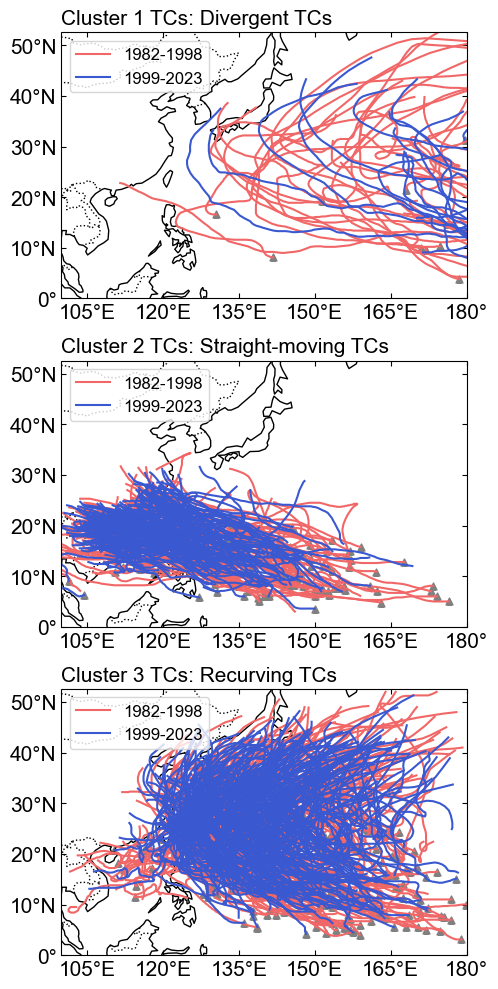

In [10]:

color4='#F16767'
color5='#3A59D1'

label_1 = '1982-1998'  # 蓝色
label_2 = '1999-2023'  # 红色

fig=plt.figure(figsize=(5,10))
ax1=plt.subplot(3,1,1,projection=ccrs.PlateCarree())
ax=ax1

df = pd.read_excel(f'Typhoon_Cluster_1.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
ax.set_extent([100, 180, 0, 45])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 51, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize=15)
ax.set_yticklabels(np.arange(0, 51, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall]  
    if year < 1999:
        color = color4
    else:
        color = color5
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1.5)
    ax.scatter(arrlon[0], arrlat[0], color='grey', s=25,marker='^')
legend_lines = [
    mlines.Line2D([], [], color=color4, linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color=color5, linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper left', fontsize=12)
ax.set_title('Cluster 1 TCs: Divergent TCs', fontsize=15,loc='left')

ax2=plt.subplot(3,1,2,projection=ccrs.PlateCarree())
ax=ax2

df = pd.read_excel(f'Typhoon_Cluster_2.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
ax.set_extent([100, 180, 0, 45])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 51, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize=15)
ax.set_yticklabels(np.arange(0, 51, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall] 
    if year < 1999:
        color = color4
    else:
        color =color5
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1.5)
    ax.scatter(arrlon[0], arrlat[0], color='grey', s=25,marker='^')
legend_lines = [
    mlines.Line2D([], [], color=color4, linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color=color5, linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper left', fontsize=12)
ax.set_title('Cluster 2 TCs: Straight-moving TCs', fontsize=15,loc='left')

ax3=plt.subplot(3,1,3,projection=ccrs.PlateCarree())
ax=ax3

df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
ax.set_extent([100, 180, 0, 45])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 51, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize=15)
ax.set_yticklabels(np.arange(0, 51, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall] 
    if year < 1999:
        color = color4
    else:
        color = color5
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1.5)
    ax.scatter(arrlon[0], arrlat[0], color='grey',s=25,marker='^')
legend_lines = [
    mlines.Line2D([], [], color=color4, linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color=color5, linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper left', fontsize=12)
ax.set_title('Cluster 3 TCs: Recurving TCs', fontsize=15,loc='left')

plt.tight_layout()
plt.savefig("01zutu102.pdf",transparent = True)
plt.show()

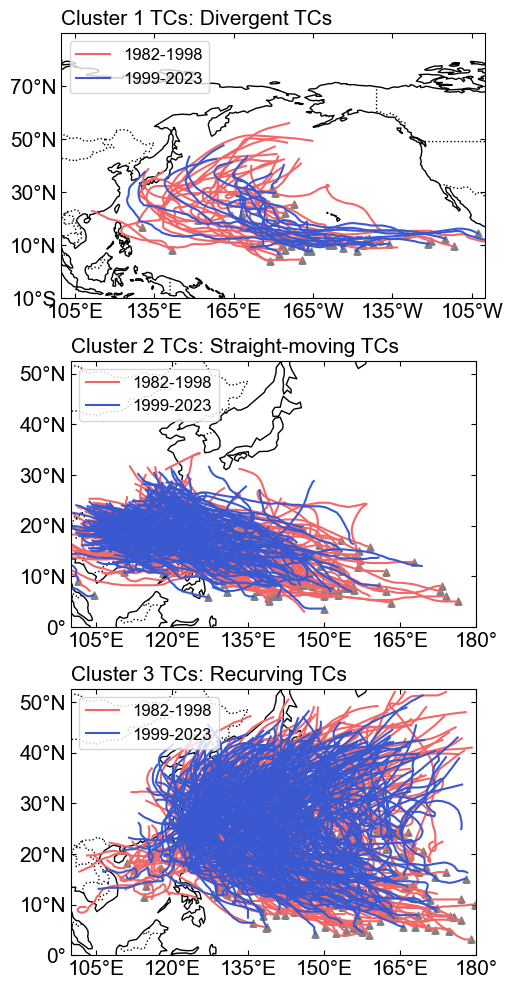

In [11]:

color4='#F16767'
color5='#3A59D1'

label_1 = '1982-1998'  # 蓝色
label_2 = '1999-2023'  # 红色

fig=plt.figure(figsize=(5,10))
ax1 = plt.subplot(3, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))
ax=ax1
ax.set_extent([100, 260, -10, 90], crs=ccrs.PlateCarree())


df = pd.read_excel(f'Typhoon_Cluster_1.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
# ax.set_extent([100, 260, 0, 45])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 261, 30), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-10, 90, 20), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 261, 30), fontsize=15)
ax.set_yticklabels(np.arange(-10, 90, 20), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall]  
    if year < 1999:
        color = color4
    else:
        color = color5
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1.5)
    ax.scatter(arrlon[0]+180, arrlat[0], color='grey', s=25,marker='^')
legend_lines = [
    mlines.Line2D([], [], color=color4, linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color=color5, linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper left', fontsize=12)
ax.set_title('Cluster 1 TCs: Divergent TCs', fontsize=15,loc='left')

ax2=plt.subplot(3,1,2,projection=ccrs.PlateCarree())
ax=ax2

df = pd.read_excel(f'Typhoon_Cluster_2.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
ax.set_extent([100, 180, 0, 45])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 51, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize=15)
ax.set_yticklabels(np.arange(0, 51, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall] 
    if year < 1999:
        color = color4
    else:
        color =color5
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1.5)
    ax.scatter(arrlon[0], arrlat[0], color='grey', s=25,marker='^')
legend_lines = [
    mlines.Line2D([], [], color=color4, linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color=color5, linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper left', fontsize=12)
ax.set_title('Cluster 2 TCs: Straight-moving TCs', fontsize=15,loc='left')

ax3=plt.subplot(3,1,3,projection=ccrs.PlateCarree())
ax=ax3

df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']
ax.set_extent([100, 180, 0, 45])
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.tick_params(left=True, right=True, top=True, bottom=True, labelleft=True, labelbottom=True, direction='in')
ax.set_xticks(np.arange(105, 181, 15), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 51, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 181, 15), fontsize=15)
ax.set_yticklabels(np.arange(0, 51, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
for i in range(len(id1)):  # 假设我们总共有20个台风
    indall = id1[i]
    year = idyr[i]
    arrlat=infile['usa_lat'][indall]#筛选的结果
    arrlon=infile['usa_lon'][indall] 
    if year < 1999:
        color = color4
    else:
        color = color5
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1.5)
    ax.scatter(arrlon[0], arrlat[0], color='grey',s=25,marker='^')
legend_lines = [
    mlines.Line2D([], [], color=color4, linewidth=1.5, label='1982-1998'),
    mlines.Line2D([], [], color=color5, linewidth=1.5, label='1999-2023')]
ax.legend(handles=legend_lines, loc='upper left', fontsize=12)
ax.set_title('Cluster 3 TCs: Recurving TCs', fontsize=15,loc='left')

plt.tight_layout()
plt.savefig("01zutu10200000.pdf",transparent = True)
plt.show()

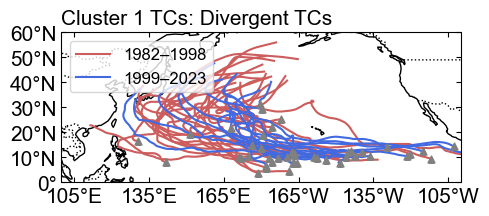

In [12]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(5, 20))
ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree(central_longitude=180))

ax.set_extent([100, 260, 0, 60], crs=ccrs.PlateCarree())


ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# 坐标轴刻度
ax.set_xticks(np.arange(105, 271, 30), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(0, 61, 10), crs=ccrs.PlateCarree())
ax.set_xticklabels(np.arange(105, 271, 30), fontsize=15)
ax.set_yticklabels(np.arange(0, 61, 10), fontsize=15)
ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
ax.tick_params(left=True, right=True, top=True, bottom=True,
               labelleft=True, labelbottom=True, direction='in')

# 数据读取
df = pd.read_excel('Typhoon_Cluster_1.xlsx')  
id1 = df['Typhoon ID']
idyr = df['year']

# 颜色设置
color4 = 'indianred'  # 1982–1998
color5 = 'royalblue'  # 1999–2023

# 绘图主循环
for i in range(len(id1)):
    indall = id1[i]
    year = idyr[i]
    arrlat = infile['usa_lat'][indall]
    arrlon = infile['usa_lon'][indall]

    color = color4 if year < 1999 else color5
    ax.plot(arrlon, arrlat, color=color, transform=ccrs.Geodetic(), linewidth=1.5)
    ax.scatter(arrlon[0]+180, arrlat[0], color='gray',
               s=25, marker='^', zorder=5)

# 图例
legend_lines = [
    mlines.Line2D([], [], color=color4, linewidth=1.5, label='1982–1998'),
    mlines.Line2D([], [], color=color5, linewidth=1.5, label='1999–2023')]
ax.legend(handles=legend_lines, loc='upper left', fontsize=12)

# 标题
ax.set_title('Cluster 1 TCs: Divergent TCs', fontsize=15,  loc='left')

plt.tight_layout()
plt.show()



In [13]:
#c3
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
tomecur3 = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
    
    numatc = indall.shape[0]

   
 
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        orilat=arrlat[0]
        endlat=arrlat[-1]
        
        orilon=arrlon[0]
        endlon=arrlon[-1]
       
        ori=[orilat,orilon]#起点集合
        end=[endlat,endlon]
        dist=great_circle(ori, end).kilometers#起点和终点的距离
        if dist!=0:
        
            coor=np.column_stack((arrlat, arrlon))#合并经纬度
            todist=0#总距离todist
            for k in range(len(coor) - 1):
                distall = great_circle(coor[k], coor[k+1]).kilometers
                todist += distall
            cur=todist/dist#一个台风的曲率

            tocur.append(cur)
   
    mecur=np.mean(tocur)#平均曲率
    tomecur3.append(mecur)
# plot_change_data(years, tomecur3, 'sinuosity', '(b) sinuosity(C3)', 17)

In [14]:
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')
year_counts = df['year'].value_counts().sort_index().values
# plot_change_data(years, year_counts, 'number', '(d) number(C3)', 17)
c3totalnumber=year_counts

In [15]:
#C1
df = pd.read_excel(f'Typhoon_Cluster_1.xlsx')

tomecur1 = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
    
    numatc = indall.shape[0]

    # 如果该年没有台风数据，则记录曲率为0
    if numatc == 0:
        tomecur1.append(0)
        continue
   
    lat = infile['usa_lat'][indall]  # 筛选的结果
    lon = infile['usa_lon'][indall]   
    win = infile['usa_wind'][indall]
    tocur = []
    
    for i in range(numatc):  # 一年的登陆台风曲率
        arrlat = np.array([num for num in lat[i].values if not np.isnan(num)])  # 将非NaN存在新的数组中
        arrlon = np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin = np.array([num for num in win[i].values if not np.isnan(num)])
        
        # 确保有足够的数据进行计算
        if len(arrlat) == 0 or len(arrlon) == 0:
            continue
        
        orilat = arrlat[0]
        endlat = arrlat[-1]
        orilon = arrlon[0]
        endlon = arrlon[-1]
       
        ori = [orilat, orilon]  # 起点集合
        end = [endlat, endlon]
        
        dist = great_circle(ori, end).kilometers  # 起点和终点的距离
        
        if dist != 0:
            coor = np.column_stack((arrlat, arrlon))  # 合并经纬度
            todist = 0  # 总距离todist
            
            for k in range(len(coor) - 1):
                distall = great_circle(coor[k], coor[k + 1]).kilometers
                todist += distall
                
            cur = todist / dist  # 一个台风的曲率
            tocur.append(cur)
   
    # 如果该年有台风数据，则计算平均曲率，否则为0
    if len(tocur) > 0:
        mecur = np.mean(tocur)  # 平均曲率
    else:
        mecur = 0
    
    tomecur1.append(mecur)

# print(tomecur1)

# plot_change_data(years, tomecur1, 'sinuosity', '(a) sinuosity(C1)', 17)

In [16]:
df = pd.read_excel(f'Typhoon_Cluster_2.xlsx')

# 要去掉的 Typhoon ID
# exclude_id = 3020

tomecur2 = []

for year in range(1982, 2024):  # 包括1982到2023年
    # 提取当前年份的数据
    year_data = df[df['year'] == year]
    
    # 获取该年份所有的 Typhoon ID，并去掉 3020
    indall = year_data['Typhoon ID'].unique()
    
    numatc = indall.shape[0]

   
 
    lat=infile['usa_lat'][indall]#筛选的结果
    lon=infile['usa_lon'][indall]   
    win=infile['usa_wind'][indall]
    tocur=[]
    for i in range(0,numatc):#一年的登陆台风曲率
        arrlat= np.array([num for num in lat[i].values if not np.isnan(num)])#将非nan存在新的数组中,一个新的数组
        arrlon= np.array([num for num in lon[i].values if not np.isnan(num)])
        arrwin= np.array([num for num in win[i].values if not np.isnan(num)])
        orilat=arrlat[0]
        endlat=arrlat[-1]
        
        orilon=arrlon[0]
        endlon=arrlon[-1]
       
        ori=[orilat,orilon]#起点集合
        end=[endlat,endlon]
        dist=great_circle(ori, end).kilometers#起点和终点的距离
        if dist!=0:
        
            coor=np.column_stack((arrlat, arrlon))#合并经纬度
            todist=0#总距离todist
            for k in range(len(coor) - 1):
                distall = great_circle(coor[k], coor[k+1]).kilometers
                todist += distall
            cur=todist/dist#一个台风的曲率
#             if cur<4.96:
                
            
           
            tocur.append(cur)
   
    mecur=np.mean(tocur)#平均曲率
    tomecur2.append(mecur)
# plot_change_data(years, tomecur2, 'sinuosity', '(b) sinuosity(C2)', 17)

## 3

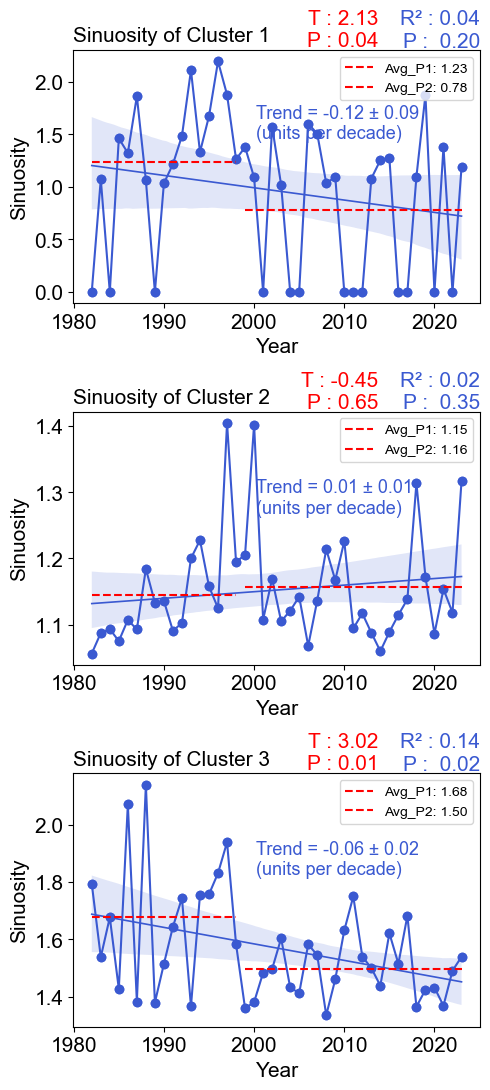

In [17]:
fig, axes = plt.subplots(3,1, figsize=(5, 11))
color1='#3A59D1'
color2=color1
color3='r'

ax=axes[0]

split_index=17
data=tomecur1
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.2})
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Sinuosity', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Sinuosity of Cluster 1',loc='left',fontsize=15)
# ax.set_title(f't: {t_stat:.2f}, P: {p_value2:.2f}',loc='right',fontsize=15)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  
# ax.text(1998,1.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} units per decade",fontsize=10,c='b')
# ax.text(2009,1.55,f'$R^2$: {r_squared:.2f}, $P$: {p_value:.2f}',fontsize=10,c='b')
ax.text(0.45,0.65,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)

ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(1, 1.07, f'P :  {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)



ax=axes[1]

split_index=17
data=tomecur2
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.2})
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Sinuosity', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Sinuosity of Cluster 2',loc='left',fontsize=15)
# ax.set_title(f't: {t_stat:.2f}, P: {p_value2:.2f}',loc='right',fontsize=15)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
# ax.text(1998,1.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} units per decade",fontsize=10,c='b')
# ax.text(2009,1.55,f'$R^2$: {r_squared:.2f}, $P$: {p_value:.2f}',fontsize=10,c='b')
ax.text(0.45,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)

ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(1, 1.07, f'P :  {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)


ax=axes[2]

split_index=17
data=tomecur3
avg_prior = np.mean(data[:split_index])
avg_post = np.mean(data[split_index:])
ax.plot(years, data, '-o', color=color1)
x=years
y=data
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value ** 2
sns.regplot(x=x, y=y, ci=95,color=color2,ax=ax, line_kws={"linewidth": 1.2})
ax.plot(years[:split_index], [avg_prior] * split_index, color=color3, linestyle='--', label=f'Avg_P1: {avg_prior:.2f}')
ax.plot(years[split_index:], [avg_post] * (len(years) - split_index), color=color3, linestyle='--', label=f'Avg_P2: {avg_post:.2f}')
ax.set_xlabel('Year', fontsize=15)
ax.set_ylabel('Sinuosity', fontsize=15)
ax.tick_params(axis='x', labelsize=15)
ax.tick_params(axis='y', labelsize=15)
ax.legend(loc=1)
P1 = data[:split_index]
P2 =  data[split_index:]
t_stat, p_value2 = stats.ttest_ind(P1, P2, equal_var=False)
ax.set_title('Sinuosity of Cluster 3',loc='left',fontsize=15)
# ax.set_title(f't: {t_stat:.2f}, P: {p_value2:.2f}',loc='right',fontsize=15)
trend_per_century = slope * 10
std_err_per_century = std_err * 10  # 将标准误差转换为每世纪的不确定性
# ax.text(1998,1.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} units per decade",fontsize=10,c='b')
# ax.text(2009,1.55,f'$R^2$: {r_squared:.2f}, $P$: {p_value:.2f}',fontsize=10,c='b')
ax.text(0.45,0.6,f"Trend = {trend_per_century:.2f} ± {std_err_per_century:.2f} \n(units per decade)",
        fontsize=13,c=color2,
       transform=ax.transAxes)

ax.text(0.75, 1.16, f'T : {t_stat:.2f}\nP : {p_value2:.2f}', ha='right', va='top', fontsize=15, color=color3, transform=ax.transAxes)
ax.text(1, 1.16, f'R² : {r_squared:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)
ax.text(1, 1.07, f'P :  {p_value:.2f}', 
        ha='right', va='top', fontsize=15, color=color2, transform=ax.transAxes)




plt.tight_layout()

plt.savefig("01zutu103.pdf",transparent = True)
plt.show()

In [18]:
# 去除 0 并计算平均值
non_zero_values = [x for x in tomecur1 if x != 0]

In [19]:
np.mean(non_zero_values)

1.3943903706128855

In [20]:
np.mean(tomecur2)

1.1521857144082521

In [21]:
np.mean(tomecur3)

1.569555195154419

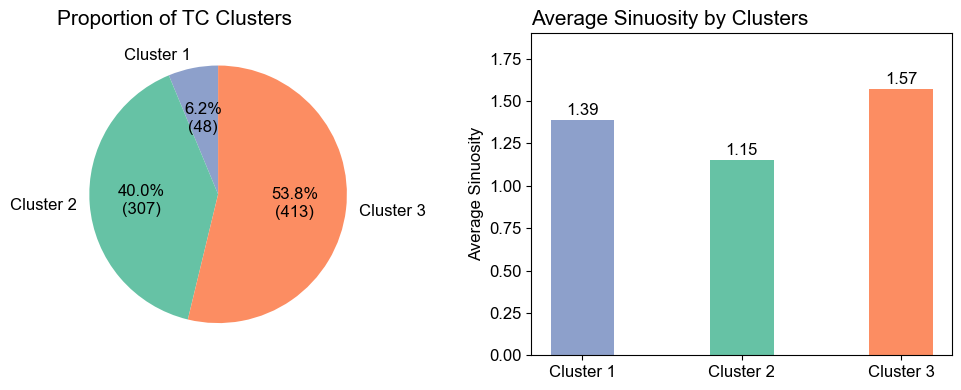

In [22]:
# 重新导入所需库
import matplotlib.pyplot as plt

# 数据
clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
counts = [48, 307, 413]
sinuosity = [1.39, 1.15, 1.57]
colors = [ '#8da0cb','#66c2a5', '#fc8d62']

# 自定义 autopct 函数：显示百分比和数量
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'
    return my_autopct

# 创建并列图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# 左图：饼图（百分比 + 数量）
wedges, texts, autotexts = ax1.pie(
    counts,
    labels=clusters,
    autopct=make_autopct(counts),
    colors=colors,
    startangle=90,
    textprops={'fontsize': 12}
)
for text in texts:
    text.set_fontsize(12)
for autotext in autotexts:
    autotext.set_fontsize(12)
ax1.set_title('Proportion of TC Clusters', fontsize=15,loc='left')

# 右图：平均弯曲度柱状图
bars = ax2.bar(clusters, sinuosity, color=colors, width=0.4)


ax2.set_title('Average Sinuosity by Clusters', fontsize=15,loc='left')
ax2.set_ylabel('Average Sinuosity', fontsize=12)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.03, f'{height:.2f}', ha='center', fontsize=12)
# 设置横轴和纵轴刻度的字体大小
ax2.tick_params(axis='x', labelsize=12)  # 横轴
ax2.tick_params(axis='y', labelsize=12)  # 纵轴
ax2.set_ylim(0, 1.9)  # 举例：设置 y 轴从 1.0 到 1.7

# 总标题与布局

plt.tight_layout()

plt.savefig("S3.pdf",transparent = True)


plt.show()


In [64]:
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')  
# 提取经纬度和台风 ID
latt = df['toorilat']
lont = df['toorilon']
typhoon_id = df['Typhoon ID']
curv=df['Curvature']
# 定义南海地理范围
south_china_sea_mask = (lont >= 100) & (lont <= 120) & (latt >= 0) & (latt <= 25)&(curv>1.57)

# 提取南海范围内的台风 ID（唯一）
south_china_sea_ids = df.loc[south_china_sea_mask, 'Typhoon ID'].unique()
num_scs_typhoons = len(south_china_sea_ids)

num_scs_typhoons

11

In [65]:
df = pd.read_excel(f'Typhoon_Cluster_3.xlsx')  
# 提取经纬度和台风 ID
latt = df['toorilat']
lont = df['toorilon']
typhoon_id = df['Typhoon ID']
curv=df['Curvature']
# 定义南海地理范围
south_china_sea_mask = (lont >= 100) & (lont <= 120) & (latt >= 0) & (latt <= 25)

# 提取南海范围内的台风 ID（唯一）
south_china_sea_ids = df.loc[south_china_sea_mask, 'Typhoon ID'].unique()
num_scs_typhoons = len(south_china_sea_ids)

num_scs_typhoons

18

In [29]:
413-18

395

In [67]:
413-11

402

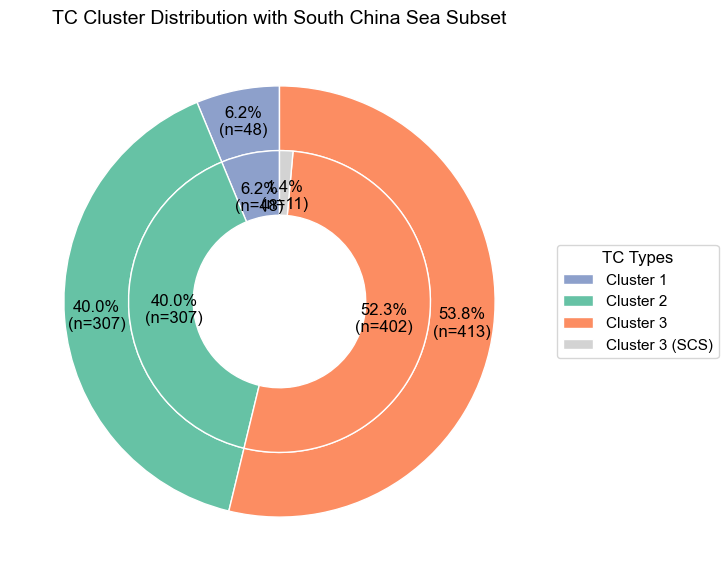

In [66]:
# 修复 unpack 错误，重新绘制简化标签的嵌套饼图
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
colors_outer = ['#8da0cb', '#66c2a5', '#fc8d62']
clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
counts_outer = [48, 307, 413]

colors_inner = ['#8da0cb', '#66c2a5', '#fc8d62', 'lightgray']
counts_inner = [48, 307, 402, 11]
labels_inner = ['', '', '', '']  # 内圈不显示标签，避免重叠

# 自定义 autopct 函数
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n(n={count})' if count > 0 else ''
    return autopct

# 创建图形
fig, ax = plt.subplots(figsize=(7, 7))

# 外圈饼图（三类台风，不显示百分比）
labels_legend = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 3 (SCS)']
colors_legend = colors_inner
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    counts_outer,
    radius=1,
    labels=[''] * 3,  # 或者保留原来的 ['Cluster 1', 'Cluster 2', 'Cluster 3']
    colors=colors_outer,
    autopct=make_autopct(counts_outer),  # 👈 添加这个
    pctdistance=0.85,  # 控制数字在外圈扇形中的位置
    wedgeprops=dict(width=0.3, edgecolor='white'),
    startangle=90,
    textprops={'fontsize': 12}
)


# 内圈饼图（细分 Cluster 3，仅显示百分比与数量）
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    counts_inner,
    radius=0.7,
    labels=labels_inner,
    labeldistance=0.75,
    colors=colors_inner,
    autopct=make_autopct(counts_inner),
    pctdistance=0.7,
    wedgeprops=dict(width=0.3, edgecolor='white'),
    startangle=90,
    textprops={'fontsize': 12}
)

# 图标题
ax.set(aspect="equal")
plt.title("TC Cluster Distribution with South China Sea Subset", fontsize=14)
ax.legend(wedges_inner, labels_legend, title="TC Types", loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11, title_fontsize=12)


plt.show()


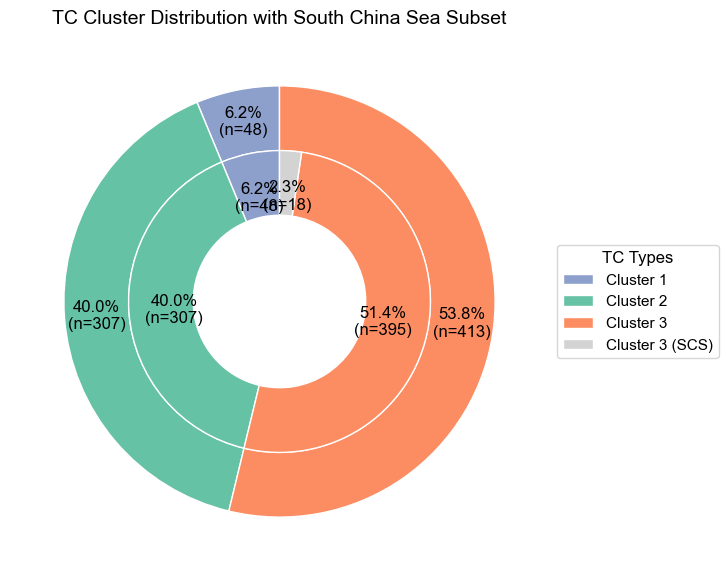

In [68]:
# 修复 unpack 错误，重新绘制简化标签的嵌套饼图
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
colors_outer = ['#8da0cb', '#66c2a5', '#fc8d62']
clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
counts_outer = [48, 307, 413]

colors_inner = ['#8da0cb', '#66c2a5', '#fc8d62', 'lightgray']
counts_inner = [48, 307, 395, 18]
labels_inner = ['', '', '', '']  # 内圈不显示标签，避免重叠

# 自定义 autopct 函数
def make_autopct(values):
    def autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n(n={count})' if count > 0 else ''
    return autopct

# 创建图形
fig, ax = plt.subplots(figsize=(7, 7))

# 外圈饼图（三类台风，不显示百分比）
labels_legend = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 3 (SCS)']
colors_legend = colors_inner
wedges_outer, texts_outer, autotexts_outer = ax.pie(
    counts_outer,
    radius=1,
    labels=[''] * 3,  # 或者保留原来的 ['Cluster 1', 'Cluster 2', 'Cluster 3']
    colors=colors_outer,
    autopct=make_autopct(counts_outer),  # 👈 添加这个
    pctdistance=0.85,  # 控制数字在外圈扇形中的位置
    wedgeprops=dict(width=0.3, edgecolor='white'),
    startangle=90,
    textprops={'fontsize': 12}
)


# 内圈饼图（细分 Cluster 3，仅显示百分比与数量）
wedges_inner, texts_inner, autotexts_inner = ax.pie(
    counts_inner,
    radius=0.7,
    labels=labels_inner,
    labeldistance=0.75,
    colors=colors_inner,
    autopct=make_autopct(counts_inner),
    pctdistance=0.7,
    wedgeprops=dict(width=0.3, edgecolor='white'),
    startangle=90,
    textprops={'fontsize': 12}
)

# 图标题
ax.set(aspect="equal")
plt.title("TC Cluster Distribution with South China Sea Subset", fontsize=14)
ax.legend(wedges_inner, labels_legend, title="TC Types", loc='center left', bbox_to_anchor=(1, 0.5), fontsize=11, title_fontsize=12)


plt.show()


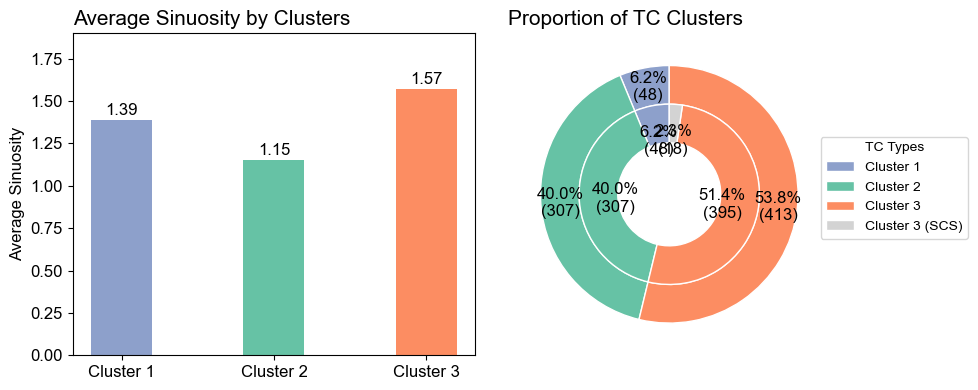

In [61]:
# 数据
clusters = ['Cluster 1', 'Cluster 2', 'Cluster 3']
counts = [48, 307, 413]
sinuosity = [1.39, 1.15, 1.57]
colors = [ '#8da0cb','#66c2a5', '#fc8d62']

# 自定义 autopct 函数：显示百分比和数量
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.1f}%\n({count})'
    return my_autopct

# 创建并列图
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(10, 4))

# 左图：饼图（百分比 + 数量）
labels_legend = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 3 (SCS)']
colors_legend = colors_inner
wedges_outer, texts_outer, autotexts_outer = ax1.pie(
    counts_outer,
    radius=1,
    labels=[''] * 3,  # 或者保留原来的 ['Cluster 1', 'Cluster 2', 'Cluster 3']
    colors=colors_outer,
    autopct=make_autopct(counts_outer),  # 👈 添加这个
    pctdistance=0.85,  # 控制数字在外圈扇形中的位置
    wedgeprops=dict(width=0.3, edgecolor='white'),
    startangle=90,
    textprops={'fontsize': 12}
)
# 内圈饼图（细分 Cluster 3，仅显示百分比与数量）
wedges_inner, texts_inner, autotexts_inner = ax1.pie(
    counts_inner,
    radius=0.7,
    labels=labels_inner,
    labeldistance=0.75,
    colors=colors_inner,
    autopct=make_autopct(counts_inner),
    pctdistance=0.6,
    wedgeprops=dict(width=0.3, edgecolor='white'),
    startangle=90,
    textprops={'fontsize': 12}
)
ax1.set_title('Proportion of TC Clusters', fontsize=15,loc='left')
ax1.legend(wedges_inner, labels_legend, title="TC Types", loc='upper right', bbox_to_anchor=(1.45, 0.7), fontsize=10, title_fontsize=10)
# bbox_to_anchor=(1, 0.5),

# 右图：平均弯曲度柱状图
bars = ax2.bar(clusters, sinuosity, color=colors, width=0.4)


ax2.set_title('Average Sinuosity by Clusters', fontsize=15,loc='left')
ax2.set_ylabel('Average Sinuosity', fontsize=12)
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 0.03, f'{height:.2f}', ha='center', fontsize=12)
# 设置横轴和纵轴刻度的字体大小
ax2.tick_params(axis='x', labelsize=12)  # 横轴
ax2.tick_params(axis='y', labelsize=12)  # 纵轴
ax2.set_ylim(0, 1.9)  # 举例：设置 y 轴从 1.0 到 1.7

# 总标题与布局

plt.tight_layout()

plt.savefig("S333.pdf",transparent = True)


plt.show()
